In [37]:
# =========================================================
# INSTALAR PACOTES
# =========================================================

packages <- c(
  "tidyverse",
  "psych",
  "e1071",
  "corrplot",
  "corrgram",
  "naniar",
  "skimr",
  "gt",
  "gtsummary",
  "performance",
  "GGally",
  "rstatix",
  "moments",
  "patchwork",
  "writexl"
)

new_packages <- packages[
  !(packages %in% installed.packages()[,"Package"])
]

if(length(new_packages) > 0){
  install.packages(new_packages)
}

lapply(packages, library, character.only = TRUE)

[[1]]
 [1] "writexl"     "patchwork"   "moments"     "rstatix"     "GGally"     
 [6] "performance" "gtsummary"   "gt"          "skimr"       "naniar"     
[11] "corrgram"    "corrplot"    "e1071"       "psych"       "stringr"    
[16] "dplyr"       "purrr"       "readr"       "tidyr"       "tibble"     
[21] "ggplot2"     "tidyverse"   "stats"       "graphics"    "grDevices"  
[26] "utils"       "datasets"    "methods"     "base"       

[[2]]
 [1] "writexl"     "patchwork"   "moments"     "rstatix"     "GGally"     
 [6] "performance" "gtsummary"   "gt"          "skimr"       "naniar"     
[11] "corrgram"    "corrplot"    "e1071"       "psych"       "stringr"    
[16] "dplyr"       "purrr"       "readr"       "tidyr"       "tibble"     
[21] "ggplot2"     "tidyverse"   "stats"       "graphics"    "grDevices"  
[26] "utils"       "datasets"    "methods"     "base"       

[[3]]
 [1] "writexl"     "patchwork"   "moments"     "rstatix"     "GGally"     
 [6] "performance" "gtsummary"   "gt"          "skimr"       "naniar"     
[11] "corrgram"    "corrplot"    "e1071"       "psych"       "stringr"    
[16] "dplyr"       "purrr"       "readr"       "tidyr"       "tibble"     
[21] "ggplot2"     "tidyverse"   "stats"       "graphics"    "grDevices"  
[26] "utils"       "datasets"    "methods"     "base"       

[[4]]
 [1] "writexl"     "patchwork"   "moments"     "rstatix"     "GGally"     
 [6] "performance" "gtsummary"   "gt"          "skimr"       "naniar"     
[11] "corrgram"    "corrplot"    "e1071"       "psych"       "stringr"    
[16] "dplyr"       "purrr"       "readr"       "tidyr"       "tibble"     
[21] "ggplot2"     "tidyverse"   "stats"       "graphics"    "grDevices"  
[26] "utils"       "datasets"    "methods"     "base"       

[[5]]
 [1] "writexl"     "patchwork"   "moments"     "rstatix"     "GGally"     
 [6] "performance" "gtsummary"   "gt"          "skimr"       "naniar"     
[11] "corrgram"    "corrplot"    "e1071"       "psych"       "stringr"    
[16] "dplyr"       "purrr"       "readr"       "tidyr"       "tibble"     
[21] "ggplot2"     "tidyverse"   "stats"       "graphics"    "grDevices"  
[26] "utils"       "datasets"    "methods"     "base"       

[[6]]
 [1] "writexl"     "patchwork"   "moments"     "rstatix"     "GGally"     
 [6] "performance" "gtsummary"   "gt"          "skimr"       "naniar"     
[11] "corrgram"    "corrplot"    "e1071"       "psych"       "stringr"    
[16] "dplyr"       "purrr"       "readr"       "tidyr"       "tibble"     
[21] "ggplot2"     "tidyverse"   "stats"       "graphics"    "grDevices"  
[26] "utils"       "datasets"    "methods"     "base"       

[[7]]
 [1] "writexl"     "patchwork"   "moments"     "rstatix"     "GGally"     
 [6] "performance" "gtsummary"   "gt"          "skimr"       "naniar"     
[11] "corrgram"    "corrplot"    "e1071"       "psych"       "stringr"    
[16] "dplyr"       "purrr"       "readr"       "tidyr"       "tibble"     
[21] "ggplot2"     "tidyverse"   "stats"       "graphics"    "grDevices"  
[26] "utils"       "datasets"    "methods"     "base"       

[[8]]
 [1] "writexl"     "patchwork"   "moments"     "rstatix"     "GGally"     
 [6] "performance" "gtsummary"   "gt"          "skimr"       "naniar"     
[11] "corrgram"    "corrplot"    "e1071"       "psych"       "stringr"    
[16] "dplyr"       "purrr"       "readr"       "tidyr"       "tibble"     
[21] "ggplot2"     "tidyverse"   "stats"       "graphics"    "grDevices"  
[26] "utils"       "datasets"    "methods"     "base"       

[[9]]
 [1] "writexl"     "patchwork"   "moments"     "rstatix"     "GGally"     
 [6] "performance" "gtsummary"   "gt"          "skimr"       "naniar"     
[11] "corrgram"    "corrplot"    "e1071"       "psych"       "stringr"    
[16] "dplyr"       "purrr"       "readr"       "tidyr"       "tibble"     
[21] "ggplot2"     "tidyverse"   "stats"       "graphics"    "grDevices"  
[26] "utils"       "datasets"    "methods"     "base"       

[[10]]
 [1] "

In [38]:
efa_data_raw <- read.delim("missing-c.txt")
names(efa_data_raw) <- gsub("\\.+", "_", names(efa_data_raw))

In [39]:
# =========================================================
# BASE NUMÉRICA
# =========================================================

efa_data <- efa_data_raw %>%
  select(where(is.numeric)) %>%
  select(-Version_Year)

### ETAPA 5 — NORMALIDADE

In [40]:
distribution_stats <- tibble(
  variable = names(efa_data),
  skewness = sapply(efa_data, e1071::skewness, na.rm = TRUE),
  kurtosis = sapply(efa_data, e1071::kurtosis, na.rm = TRUE)
)

summary(distribution_stats)

      variable     skewness          kurtosis      
 Length   :35   Min.   :-0.4031   Min.   :-1.3760  
 N.unique :35   1st Qu.: 0.1167   1st Qu.:-0.7324  
 N.blank  : 0   Median : 0.2112   Median :-0.3114  
 Min.nchar:13   Mean   : 0.4240   Mean   : 0.1033  
 Max.nchar:39   3rd Qu.: 0.4950   3rd Qu.: 0.2485  
                Max.   : 2.4419   Max.   : 5.2843  

Warning message:
"Removed 26 rows containing non-finite outside the scale range (`stat_density()`)."


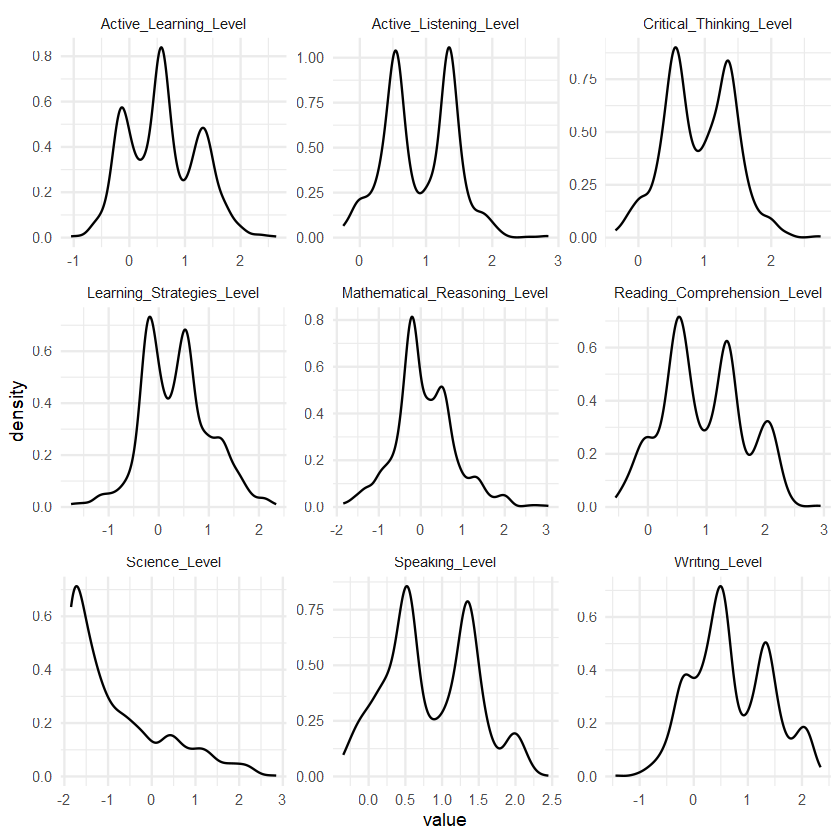

In [41]:
selected_vars <- names(efa_data)[1:min(9, ncol(efa_data))]

density_data <- efa_data_raw %>%
  select(Version_Year, all_of(selected_vars)) %>%
  pivot_longer(-Version_Year, names_to = "variable", values_to = "value")

ggplot(density_data, aes(x = value)) +
  geom_density() +
  facet_wrap(~variable, scales = "free") +
  theme_minimal()

Warning message:
"Removed 26 rows containing non-finite outside the scale range (`stat_density()`)."


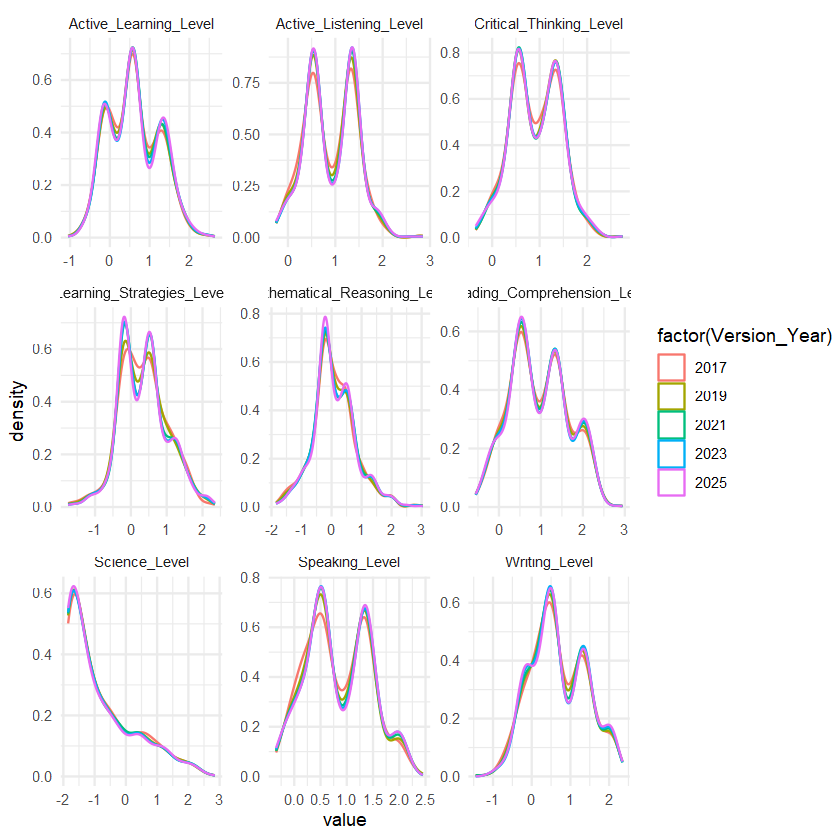

In [42]:
ggplot(density_data, aes(x = value, color = factor(Version_Year))) +
  geom_density() +
  facet_wrap(~variable, scales = "free") +
  theme_minimal()

### 5. PIPELINE DE CORRELAÇÃO + LIMPEZA

In [43]:
remove_high_cor <- function(cor_mat, cutoff = 0.95){

  cor_abs <- abs(cor_mat)
  diag(cor_abs) <- 0

  removed <- c()

  while(max(cor_abs) > cutoff){

    idx <- which(cor_abs == max(cor_abs), arr.ind = TRUE)[1,]

    v1 <- colnames(cor_abs)[idx[1]]
    v2 <- colnames(cor_abs)[idx[2]]

    mean1 <- mean(cor_abs[v1, ])
    mean2 <- mean(cor_abs[v2, ])

    drop_var <- ifelse(mean1 > mean2, v1, v2)

    removed <- c(removed, drop_var)

    cor_abs <- cor_abs[
      !rownames(cor_abs) %in% drop_var,
      !colnames(cor_abs) %in% drop_var
    ]
  }

  unique(removed)
}

In [44]:
vars_clean <- efa_data %>%
  select(where(~ !all(is.na(.)))) %>%
  select(where(~ sd(., na.rm = TRUE) > 0)) %>%
  mutate(across(everything(), ~ ifelse(is.na(.), median(., na.rm = TRUE), .)))

In [45]:
cor_mat <- cor(vars_clean, method = "spearman", use = "pairwise.complete.obs")

### 6. KMO + BARTLETT (GLOBAL)

In [46]:
kmo_global <- psych::KMO(cor_mat)
bart_global <- psych::cortest.bartlett(cor_mat, n = nrow(vars_clean))

kmo_global
bart_global

Kaiser-Meyer-Olkin factor adequacy
Call: psych::KMO(r = cor_mat)
Overall MSA =  0.97
MSA for each item = 
            Reading_Comprehension_Level                  Active_Listening_Level 
                                   0.98                                    0.98 
                          Writing_Level                          Speaking_Level 
                                   0.98                                    0.98 
           Mathematical_Reasoning_Level                           Science_Level 
                                   0.97                                    0.97 
                Critical_Thinking_Level                   Active_Learning_Level 
                                   0.99                                    0.99 
              Learning_Strategies_Level                        Monitoring_Level 
                                   0.97                                    0.98 
            Social_Perceptiveness_Level                      Coordination_Level 
   

$chisq
[1] 179060.4

$p.value
[1] 0

$df
[1] 595

### 7. KMO POR ANO (ROBUSTO)

In [47]:
years <- unique(efa_data_raw$Version_Year)

kmo_years <- list()

for(y in years){

  temp <- efa_data_raw %>%
    filter(Version_Year == y) %>%
    select(where(is.numeric)) %>%
    select(-Version_Year) %>%
    select(where(~ !all(is.na(.)))) %>%
    select(where(~ sd(., na.rm = TRUE) > 0)) %>%
    mutate(across(everything(), ~ ifelse(is.na(.), median(., na.rm = TRUE), .)))

  cor_temp <- cor(temp, method = "spearman", use = "pairwise.complete.obs")

  drop <- remove_high_cor(cor_temp)

  if(length(drop) > 0){
    temp <- temp %>% select(-all_of(drop))
  }

  kmo_years[[as.character(y)]] <- psych::KMO(cor(temp))$MSA
}

In [48]:
kmo_years

$`2017`
[1] 0.9548863

$`2019`
[1] 0.9544662

$`2021`
[1] 0.9547008

$`2023`
[1] 0.9553766

$`2025`
[1] 0.9562661

### BARTLETT GLOBAL

In [49]:
# =========================================================
# BARTLETT TEST - GLOBAL (EFA ADEQUACY)
# =========================================================

cor_mat <- cor(
  vars_clean,
  method = "spearman",
  use = "pairwise.complete.obs"
)

bart_global <- psych::cortest.bartlett(
  cor_mat,
  n = nrow(vars_clean)
)

bart_global

$chisq
[1] 179060.4

$p.value
[1] 0

$df
[1] 595

In [50]:
# =========================================================
# BARTLETT BY YEAR
# =========================================================

bart_years <- list()
bart_years_table <- list()

for(y in years){

  temp <- efa_data_raw %>%
    filter(Version_Year == y) %>%
    select(where(is.numeric)) %>%
    select(-Version_Year) %>%
    select(where(~ !all(is.na(.)))) %>%
    select(where(~ sd(., na.rm = TRUE) > 0)) %>%
    mutate(across(everything(), ~ ifelse(is.na(.), median(., na.rm = TRUE), .)))

  cor_temp <- cor(temp, method = "spearman", use = "pairwise.complete.obs")

  drop <- remove_high_cor(cor_temp)

  if(length(drop) > 0){
    temp <- temp %>% select(-all_of(drop))
  }

  cor_temp <- cor(temp, method = "spearman")

  bart_temp <- psych::cortest.bartlett(
    cor_temp,
    n = nrow(temp)
  )

  bart_years[[as.character(y)]] <- bart_temp

  bart_years_table[[as.character(y)]] <- tibble(
    year = y,
    chi_square = bart_temp$chisq,
    df = bart_temp$df,
    p_value = bart_temp$p.value
  )
}

In [51]:
# =========================================================
# BARTLETT PANEL SUMMARY
# =========================================================

bart_years_df <- bind_rows(bart_years_table)

bart_years_df

year,chi_square,df,p_value
<int>,<dbl>,<dbl>,<dbl>
2017,29686.93,496,0
2019,30081.08,496,0
2021,30237.76,496,0
2023,30408.11,496,0
2025,30293.38,496,0


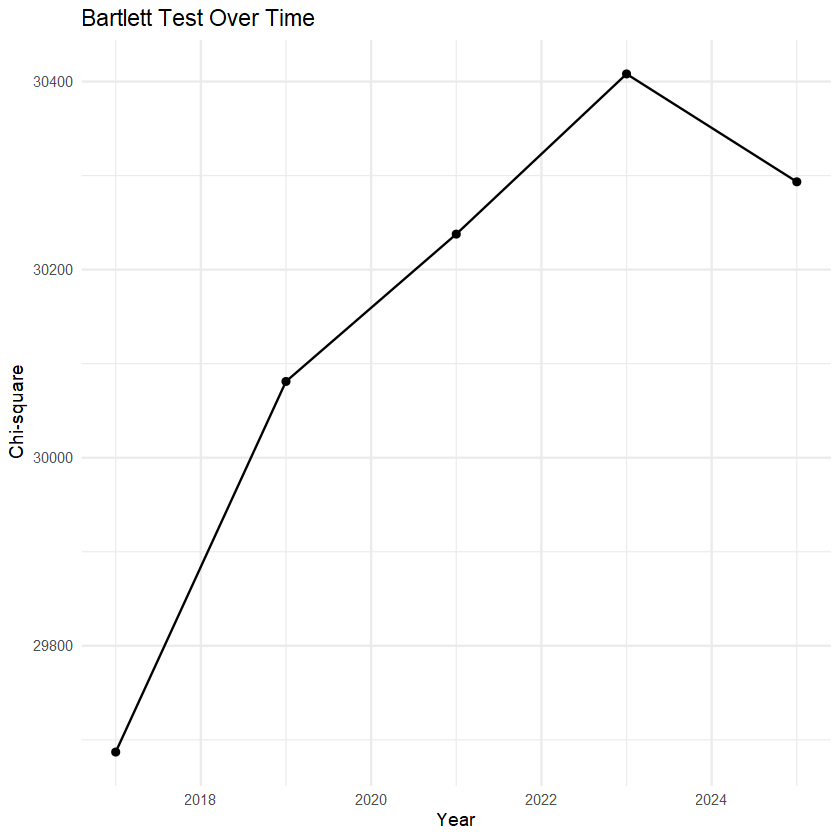

In [52]:
# =========================================================
# BARTLETT OVER TIME
# =========================================================

ggplot(bart_years_df, aes(x = year, y = chi_square)) +
  geom_line() +
  geom_point() +
  theme_minimal() +
  labs(
    title = "Bartlett Test Over Time",
    x = "Year",
    y = "Chi-square"
  )

### 8. MSA ITEM LEVEL

In [53]:
msa_items <- tibble(
  variable = names(kmo_global$MSAi),
  msa = as.numeric(kmo_global$MSAi)
) %>%
  arrange(msa) %>%
  mutate(
    class = case_when(
      msa >= .90 ~ "marvelous",
      msa >= .80 ~ "meritorious",
      msa >= .70 ~ "middling",
      msa >= .60 ~ "mediocre",
      msa >= .50 ~ "miserable",
      TRUE ~ "remove"
    )
  )

head(msa_items, 20)

variable,msa,class
<chr>,<dbl>,<chr>
Management_of_Financial_Resources_Level,0.9036791,marvelous
Operations_Monitoring_Level,0.9067985,marvelous
Management_of_Material_Resources_Level,0.9071064,marvelous
Quality_Control_Analysis_Level,0.9177617,marvelous
Repairing_Level,0.9210119,marvelous
Equipment_Maintenance_Level,0.9252352,marvelous
Troubleshooting_Level,0.9409635,marvelous
Operation_and_Control_Level,0.9473343,marvelous
Technology_Design_Level,0.9483034,marvelous


### 9. MATRIZ FINAL EFA

In [54]:
efa_final <- efa_data_raw

vars_efa <- efa_final %>%
  select(where(is.numeric)) %>%
  select(-Version_Year) %>%
  names()

# remover zero variance
vars_efa <- vars_efa[
  sapply(efa_final[vars_efa], function(x){
    sd(x, na.rm = TRUE) > 0
  })
]

# imputação
efa_final[vars_efa] <- lapply(efa_final[vars_efa], function(x){
  x[is.na(x)] <- median(x, na.rm = TRUE)
  x
})

# correlação final
cor_final <- cor(efa_final[vars_efa], method = "spearman")

# remover alta correlação
remove_vars <- remove_high_cor(cor_final)
vars_efa <- setdiff(vars_efa, remove_vars)

# KMO final
kmo_final <- psych::KMO(cor(efa_final[vars_efa], method = "spearman"))
kmo_final

Kaiser-Meyer-Olkin factor adequacy
Call: psych::KMO(r = cor(efa_final[vars_efa], method = "spearman"))
Overall MSA =  0.96
MSA for each item = 
            Reading_Comprehension_Level                  Active_Listening_Level 
                                   0.98                                    0.98 
                         Speaking_Level            Mathematical_Reasoning_Level 
                                   0.98                                    0.97 
                          Science_Level                 Critical_Thinking_Level 
                                   0.97                                    0.99 
                  Active_Learning_Level               Learning_Strategies_Level 
                                   0.98                                    0.97 
                       Monitoring_Level             Social_Perceptiveness_Level 
                                   0.98                                    0.97 
                     Coordination_Level       

### 10. EXPORTAÇÃO FINAL (TXT PARA EFA/CFA)

In [55]:
# =========================================================
# BASE FINAL EXPORTÁVEL
# =========================================================

write.table(
  efa_final,
  file = "adequacy-c.txt",
  sep = "\t",
  row.names = FALSE,
  quote = FALSE,
    fileEncoding = "UTF-8"
)